In [10]:
import collections
import matplotlib.pyplot as plt
from IPython import display
import numpy as np
import copy
import math

import torch
from torch import Tensor, nn, optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from common.model.cnn_simple import CIFAR10ReLU
from common.const import DATASET_PATH
from common.util import *
from common.meta import MetaData
#from common.optimise import OptimiserEtaSoftmaxArmihoNorm2Base, OptimiserEtaSoftmaxArmihoNorm1Base, reduce_to_active
from common.optimise_v3 import NetLineStepProcessor
#from common.dropout_manual import DropoutManual

from torchvision.datasets import CIFAR10
from torchvision import transforms

import logging

In [11]:
logging.basicConfig(filename="log_convcrity_cifar10_epochsd_v3.log",
                level=logging.INFO,
                format="%(levelname)s: %(asctime)s %(message)s")
#                datefmt="%m/%d/%Y %I:%M:%S")


#### CIFAR10 dataset

In [12]:
# Convert from PIL to torch.Tensort
# and normalize each pixel from [0, 255] range to [0.0, 1.0]
base_transforms = transforms.ToTensor()

# An augmentation that randomly (with a probability equal to 0.5)
# flips the image horizontally
# This will prevent overfitting and make the model more robust
aug_transforms = transforms.RandomHorizontalFlip(p=0.5)

# Gather all transforms together
train_transforms = transforms.Compose([
    base_transforms,
    aug_transforms
])

train_dataset = CIFAR10(root=DATASET_PATH, train=True, download=True, transform=train_transforms)

# Note that we only use `base_transforms` for test dataset
test_dataset = CIFAR10(root=DATASET_PATH, train=False, download=True, transform=base_transforms)

Files already downloaded and verified
Files already downloaded and verified


In [13]:
BATCH_SIZE = 64 #64 #32

# `pin_memory` speed up processing if you use GPU
# `num_workers` also speed up processing since use additional process
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=0, pin_memory=True)
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                             num_workers=0, pin_memory=True)

In [14]:
#Weights distribution variances are set as in (5.67)
slope_plus, slope_minus=1.0, 0.1
cb, cw = 0, 2.0/(slope_plus**2.0 + slope_minus**2.0)

INPUT_DIM=32*32 #*3 USING 0.299 ∙ Red + 0.587 ∙ Green + 0.114 ∙ Blue for gray-transform
OUTPUT_DIM = 10 #26  # num of classes

lb, lw = 0.005, 5.0
meta = MetaData(input_dim = INPUT_DIM, output_dim = OUTPUT_DIM, batch_size = BATCH_SIZE, lb = 0.005, lw = 5.0, reduction='mean')

DEVICE = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')


##### UTILS

#### Compare optimisers

In [15]:
def print_comparison(HISTORY_NORM2, HISTORY_OPTFIX):
    #start_epoch, finish_epoch = 10, 20
    display.clear_output()
    fig, axes = plt.subplots(2, 1, figsize=(12, 16))
    axes[0].set_title('Loss (Cross Entropy)')
    #axes[0].set_xlim(start_epoch-1, finish_epoch)
    #axes[0].plot(HISTORY_NORM1['train_loss'][2:40], color='g', ls='dotted', alpha=.5, label='Train norm1')
    #axes[0].plot(HISTORY_NORM2['train_loss'][2:40], color='b', ls='dotted', alpha=.5, label='Train norm2')
    #axes[0].plot(HISTORY_ZHS['train_loss'][2:40], color='r', ls='dotted', alpha=.5, label='Train Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['train_loss'][2:40], color='orange', ls='dotted', alpha=.5, label='Train Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['train_loss'][2:40], color='brown', ls='dotted', alpha=.5, label='Train direct Zhang-lambda')
    #axes[0].plot(HISTORY_NORM1['test_loss'], color='g', alpha=.5, label='Test norm1')
    axes[0].plot(HISTORY_NORM2['test_loss'], color='b', alpha=.5, label='Test norm2')
    #axes[0].plot(HISTORY_ZHS['test_loss'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[0].plot(HISTORY_ZHL['test_loss'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[0].plot(HISTORY_OPTADA['test_loss'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[0].plot(HISTORY_OPTFIX['test_loss'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[0].grid()
    axes[0].legend()
    axes[0].set_xlabel("Epoch (series of gradient descent steps)")
    axes[0].set_ylabel("Loss value")

    axes[1].set_title('Accuracy')
    #axes[1].set_xlim(10, 20)
    #axes[1].plot(HISTORY_NORM1['train_accuracy'][2:40], color='g', alpha=.5, ls='dotted', label='Train norm1')
    #axes[1].plot(HISTORY_NORM2['train_accuracy'][2:40], color='b', alpha=.5, ls='dotted', label='Train norm2')
    #axes[1].plot(HISTORY_ZHS['train_accuracy'][2:40], color='r', alpha=.5, ls='dotted', label='Train Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['train_accuracy'][2:40], color='orange', alpha=.5, ls='dotted', label='Train Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['train_accuracy'][2:40], color='brown', alpha=.5, ls='dotted', label='Train direct Zhang-lambda')
    #axes[1].plot(HISTORY_NORM1['test_accuracy'], color='g', alpha=.5, label='Test norm1')
    axes[1].plot(HISTORY_NORM2['test_accuracy'], color='b', alpha=.5, label='Test norm2')
    #axes[1].plot(HISTORY_ZHS['test_accuracy'], color='r', alpha=.5, label='Test Zhang-simple')
    #axes[1].plot(HISTORY_ZHL['test_accuracy'], color='orange', alpha=.5, label='Test Zhang-lambda')
    #axes[1].plot(HISTORY_OPTADA['test_accuracy'], color='purple', alpha=.5, label='Test Zhang-simple optimiser')
    axes[1].plot(HISTORY_OPTFIX['test_accuracy'], color='grey', alpha=.5, label='Test Nesterov-fix optimiser')
    axes[1].grid()
    axes[1].legend()
    axes[1].set_xlabel("Epoch (series of gradient descent steps)")
    axes[1].set_ylabel("Accuracy value")

    #fig.tight_layout()
    #fig.subplots_adjust(top=0.95)
    dummy=fig.suptitle("Comparison for the same FFN-structure for different optimisers")

    plt.show()

#### Reference CNN

In [16]:
def make_model(dropout_const = 1.0):
    
    model = nn.Sequential(
        nn.Conv2d(in_channels=3, out_channels=16, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=16, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Conv2d(in_channels=32, out_channels=32, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.Conv2d(in_channels=32, out_channels=64, kernel_size=(3, 3), padding='same'),
        nn.LeakyReLU(0.1),
        nn.MaxPool2d(kernel_size = (2,2)),
        nn.Dropout(0.25*dropout_const),
        nn.Flatten(),
        nn.Linear(4096, 256),
        nn.LeakyReLU(0.1),
        nn.Dropout(0.5*dropout_const),
        nn.Linear(256, 10)
    )

    return model

In [17]:
#HISTORY_NORM1 = collections.defaultdict(list)
HISTORY_NORM2 = collections.defaultdict(list)
HISTORY_OPTFIX = collections.defaultdict(list)

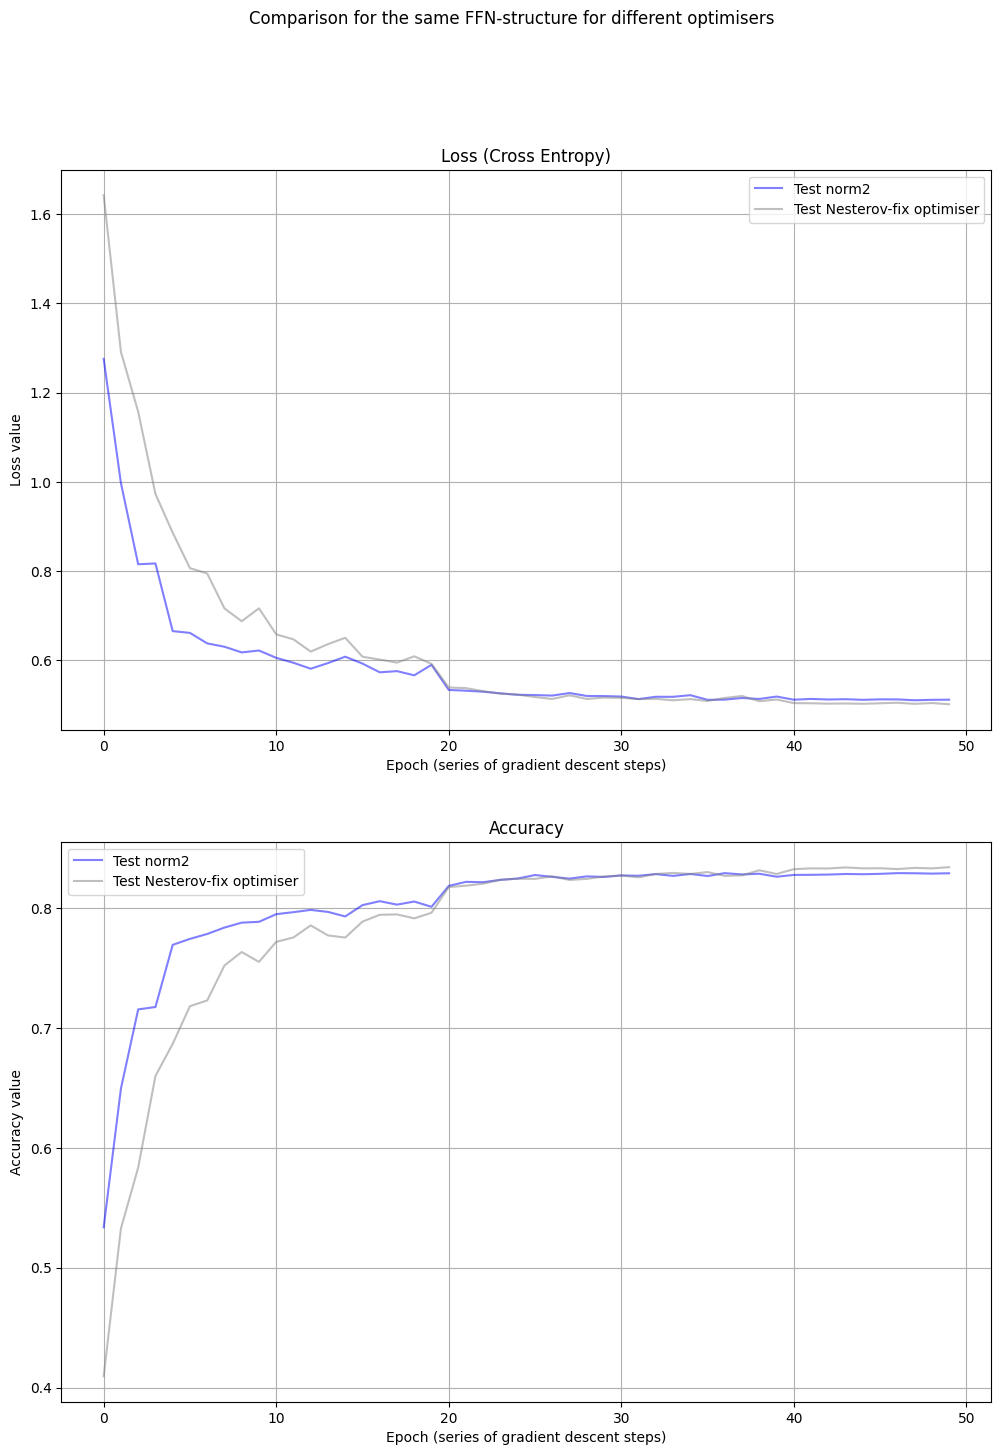

accuracy
orm2=[0.5337380573248408, 0.6493829617834395, 0.7154657643312102, 0.7174562101910829, 0.7693073248407644, 0.7742834394904459, 0.7783638535031847, 0.7837380573248408, 0.7878184713375797, 0.788515127388535, 0.7948845541401274, 0.7965764331210191, 0.7984673566878981, 0.7967754777070064, 0.7929936305732485, 0.8024482484076433, 0.8057324840764332, 0.8028463375796179, 0.8054339171974523, 0.8010549363057324, 0.8184713375796179, 0.8218550955414012, 0.8215565286624203, 0.823546974522293, 0.8246417197452229, 0.8275278662420382, 0.8260350318471338, 0.8245421974522293, 0.8264331210191083, 0.8259355095541401, 0.8272292993630573, 0.8269307324840764, 0.8283240445859873, 0.8268312101910829, 0.8284235668789809, 0.8267316878980892, 0.8291202229299363, 0.8280254777070064, 0.8286226114649682, 0.8261345541401274, 0.8276273885350318, 0.8277269108280255, 0.8279259554140127, 0.8284235668789809, 0.8282245222929936, 0.8285230891719745, 0.8291202229299363, 0.8290207006369427, 0.8287221337579618, 0.82902

In [18]:
def test_loop(testNet, test_loss_meter, test_accuracy_meter):
    for test_batch in test_dataloader:
        images, labels = test_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        with torch.no_grad():
            logits = testNet.forward(images)

            zz_logits = np.transpose(logits.detach().cpu().numpy())
            prediction = logits.argmax(dim=-1).detach()
            loss = loss_crossentropy(zz_logits, labels)
            test_loss_meter.update(loss)
            test_accuracy_meter.update(calculate_accuracy(prediction, labels))

NUM_EPOCH = 50
eta_fixed = 0.01

testOptfix = make_model().to(DEVICE)
loss_fnFix = nn.CrossEntropyLoss()
optimizerFix = optim.SGD(testOptfix.parameters(), lr=eta_fixed, momentum=0.9, nesterov=True)
params = {k: v.detach().cpu().numpy().copy() for k, v in testOptfix.named_parameters()}

testNorm2S = copy.deepcopy(testOptfix)
stepProcessor = NetLineStepProcessor(testNorm2S, nn.CrossEntropyLoss(), meta, DEVICE)

do_dropout, epoch_switch=False, 100
for epoch in range(NUM_EPOCH):
    loss_data = HISTORY_NORM2['test_loss']
    if len(loss_data) > 1 and ((loss_data[-2]-loss_data[-1])/loss_data[-1]) < 0.00001:
        do_dropout = True
    epoch_switch = min(epoch, epoch_switch) if do_dropout else epoch_switch

    lr = eta_fixed if epoch < 20 else eta_fixed * 0.1 if epoch < 40 else eta_fixed * 0.01

    stepProcessor.c1 = 0.05
    stepProcessor.eta_max = 5*lr if not do_dropout else lr
    stepProcessor.eta_cos_negative = lr
    stepProcessor.eta_min = 0.01* lr #if not do_dropout else lr
    stepProcessor.eta0 = 0.000_000_25 #0.000_000_25-no-dropout #0.000_000_5
    stepProcessor.iter_max = 1
    stepProcessor.momentum_gradient_smoothing_coefficient = 10.0
    
    stepProcessor.training_mode=do_dropout
    testNorm2S.train(False)
    step_params = {"estimation_type": 'analytic-norm2'} if not do_dropout \
        else {"estimation_type": 'analytic-norm2', "check_additional": False} #, 'check_armiho': False

    optimizerFix.param_groups[0]['lr'] = lr
    testOptfix.train(True)

    train_eta2raw_meter, train_eta2_meter, train_armiho2_meter, train_wolf2_meter\
          = AverageMeter(), AverageMeter(), AverageMeter(), AverageMeter()

    iter=0
    for train_batch in train_dataloader:
        images, labels = train_batch
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        pp = labels_to_softhot(labels, meta.output_dim)
        iter+=1

        logging.info("##\n --==Epoch={}, iter={}==--".format(epoch, iter))
        logging.info("####Step with net-line norm2")
        step_result = stepProcessor.step(labels, images, momentum=0.9, nesterov=True, step_params=step_params)
        train_eta2_meter.update(step_result.eta)
        train_eta2raw_meter.update(step_result.eta_raw)
        train_armiho2_meter.update(step_result.ck_armiho)
        train_wolf2_meter.update(step_result.ck_wolf)

        logging.info("####Step with Optim-fix, eta={}".format(optimizerFix.param_groups[0]['lr']))
        logitsOptfix = testOptfix.forward(images)
        lossOptfix = loss_fnFix(logitsOptfix, labels)
        optimizerFix.zero_grad()
        lossOptfix.backward()
        optimizerFix.step()

    HISTORY_NORM2['train_eta'].append(train_eta2_meter.avg)
    HISTORY_NORM2['train_eta_raw'].append(train_eta2raw_meter.avg)
    HISTORY_NORM2['train_armiho'].append(train_armiho2_meter.avg)
    HISTORY_NORM2['train_wolf'].append(train_wolf2_meter.avg)

    testNorm2S.eval()
    testOptfix.eval()
    # testing loop
    test_loss2S_meter, test_accuracy2S_meter = AverageMeter(), AverageMeter(),
    test_loop(testNorm2S, test_loss2S_meter, test_accuracy2S_meter)
    HISTORY_NORM2['test_loss'].append(test_loss2S_meter.avg)
    HISTORY_NORM2['test_accuracy'].append(test_accuracy2S_meter.avg) 

    test_lossOptfix_meter, test_accuracyOptfix_meter = AverageMeter(), AverageMeter(),
    test_loop(testOptfix, test_lossOptfix_meter, test_accuracyOptfix_meter)
    HISTORY_OPTFIX['test_loss'].append(test_lossOptfix_meter.avg)
    HISTORY_OPTFIX['test_accuracy'].append(test_accuracyOptfix_meter.avg)
    
    print_comparison(HISTORY_NORM2, HISTORY_OPTFIX)
    print("accuracy\norm2={}, \naccuracy Nesterov-fix={}; switch={}"\
          .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy'], epoch_switch))


In [19]:
HISTORY_NORM2['train_armiho']


[0.7313723119265375,
 0.7056419171581075,
 0.6704449605599281,
 0.6368128440401943,
 0.9284574887904133,
 0.9293436200064737,
 0.9284701542025658,
 0.925798005373439,
 0.9243718180816898,
 0.9213764740220296,
 0.9241516191422765,
 0.9180151593026602,
 0.921402891484744,
 0.919134202136828,
 0.9175893231576943,
 0.9169242921525395,
 0.9163720620424239,
 0.9186990161910338,
 0.9186853827589309,
 0.917876669835759,
 0.9987045881752358,
 0.9994416868811858,
 0.9989832642236436,
 0.999219244402791,
 0.9994129736945461,
 0.9987741923574242,
 0.9990656833081927,
 0.9993195294250702,
 0.9988604296701967,
 0.9990452823836499,
 0.9992738165892336,
 0.9986926218787974,
 0.9988360525447952,
 0.9986016322157939,
 0.9986624065187409,
 0.9989330950892019,
 0.998426645871165,
 0.9988155319633459,
 0.9989244365107113,
 0.9985779495906085,
 1.0708337475343686,
 1.0724859630727062,
 1.0709508741705334,
 1.0735822478069574,
 1.071242455016434,
 1.0708725371709578,
 1.0732471481525394,
 1.0729910230530604,

In [20]:
HISTORY_NORM2['train_wolf']

[0.531093997467078,
 0.5344873579321667,
 0.5023894798008348,
 0.4703820615666313,
 0.8659279797830518,
 0.8679437103773543,
 0.8661864567272021,
 0.8623516016669323,
 0.8593539283834996,
 0.854948480416642,
 0.8591326804772101,
 0.8492238754848573,
 0.8542975402156804,
 0.8507382823677868,
 0.8488096041993763,
 0.8471052019983715,
 0.8465969002778903,
 0.8501022971029892,
 0.8504298862485237,
 0.8489516392931183,
 0.9783235563982108,
 0.9785870575216082,
 0.9780956374114745,
 0.9780639157822655,
 0.9782386406471599,
 0.9774605465310823,
 0.9780797777895808,
 0.978002672233804,
 0.9774247402145002,
 0.9775225495208052,
 0.9778906627953232,
 0.9770282939528645,
 0.9770465635290675,
 0.9768788011424747,
 0.9768620974338053,
 0.9771599424589025,
 0.9763863953137318,
 0.9770193289374945,
 0.9766620291560434,
 0.9764407906202037,
 0.9266895039822213,
 0.9250968164007968,
 0.9266183197187973,
 0.924040834429445,
 0.9263353205716846,
 0.9266839949752291,
 0.9243853202021891,
 0.92450910235116

In [21]:
HISTORY_NORM2['train_eta']

[0.027237683184050003,
 0.03766961069942273,
 0.03982907663368534,
 0.039472215416621007,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.009999999999999844,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.0010000000000000007,
 0.00010000000000000155,
 0.00010000000000000155,
 0.000100000

In [22]:
HISTORY_NORM2['train_eta_raw']

[0.03648999697716095,
 0.03860196779451837,
 0.04050713245672297,
 0.03978125425664526,
 0.03526168690895789,
 0.03600708004961119,
 0.03525115843051445,
 0.035195017445069456,
 0.03463236557007,
 0.03434468974528828,
 0.03406510459704449,
 0.03354605229968029,
 0.03362669720053601,
 0.03304145765858037,
 0.03236572195453451,
 0.03254861088325618,
 0.0321400111551931,
 0.03253279219457182,
 0.03214992406775983,
 0.031641006529052815,
 0.010676773230459069,
 0.010497990910243726,
 0.010328511348897298,
 0.0102320214028074,
 0.010256297358987428,
 0.010044553127096999,
 0.010151463766728118,
 0.0098838349739203,
 0.009782183473882324,
 0.009801342687496953,
 0.00982023117734333,
 0.00973957205836817,
 0.009699041193166159,
 0.00966738028211743,
 0.009592353264251587,
 0.009599191385486558,
 0.009484416099896127,
 0.009527173631702331,
 0.009426270548243385,
 0.009417824957019781,
 0.0029898885174850626,
 0.0029768426462543113,
 0.0029700026510993613,
 0.0030244188954672044,
 0.0029607588

In [23]:
print("accuracy norm2={}, \naccuracy Nesterov-fix={}"\
        .format(HISTORY_NORM2['test_accuracy'], HISTORY_OPTFIX['test_accuracy']))

accuracy norm2=[0.5337380573248408, 0.6493829617834395, 0.7154657643312102, 0.7174562101910829, 0.7693073248407644, 0.7742834394904459, 0.7783638535031847, 0.7837380573248408, 0.7878184713375797, 0.788515127388535, 0.7948845541401274, 0.7965764331210191, 0.7984673566878981, 0.7967754777070064, 0.7929936305732485, 0.8024482484076433, 0.8057324840764332, 0.8028463375796179, 0.8054339171974523, 0.8010549363057324, 0.8184713375796179, 0.8218550955414012, 0.8215565286624203, 0.823546974522293, 0.8246417197452229, 0.8275278662420382, 0.8260350318471338, 0.8245421974522293, 0.8264331210191083, 0.8259355095541401, 0.8272292993630573, 0.8269307324840764, 0.8283240445859873, 0.8268312101910829, 0.8284235668789809, 0.8267316878980892, 0.8291202229299363, 0.8280254777070064, 0.8286226114649682, 0.8261345541401274, 0.8276273885350318, 0.8277269108280255, 0.8279259554140127, 0.8284235668789809, 0.8282245222929936, 0.8285230891719745, 0.8291202229299363, 0.8290207006369427, 0.8287221337579618, 0.8290